In [1]:
import os
import math
import graphufs
import xrft

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import typing as t
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import colormaps as cm
import matplotlib.cm as mcm

from matplotlib.lines import Line2D
from weatherbench2 import schema

#from weatherbench2.derived_variables import ZonalEnergySpectrum

In [2]:
plt.style.use("graphufs.plotstyle")

In [3]:
class DerivedVariable:
  """Derived variable base class."""

  @property
  def base_variables(self) -> list[str]:
    """Return a list of base variables."""
    return []

  @property
  def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
    """Return core dimensions needed for computing this variable.

    Returns a tuple, where the first element is a tuple of all core dimensions
    for input (base) variables, and the second element is a tuple of all core
    dimensions on the output. For more details on the concept of "core
    dimensions", see xarray.apply_ufunc.
    """
    raise NotImplementedError

  @property
  def all_input_core_dims(self) -> set[str]:
    """The set of all input core dimensions."""
    return set().union(*self.core_dims[0])

  def compute(self, dataset: xr.Dataset) -> xr.DataArray:
    """Compute derived variable, returning it in a new DataArray."""
    raise NotImplementedError

In [4]:
class Vorticity(DerivedVariable):
    """Compute relative vorticity from velocity fields."""

    R = 6.371e6  # Earth's radius [m]

    @property
    def base_variables(self) -> list[str]:
        return ["uo", "vo"]

    @property
    def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
        return (
            [["time", "lat", "lon"], ["time", "lat", "lon"]],   # uo, vo
            ["time", "lat", "lon"],                             # vorticity
        )

    def compute(self, dataset: xr.Dataset) -> xr.DataArray:
        u = dataset["uo"]
        v = dataset["vo"]
        lat = u["lat"]
        lon = u["lon"]

        lat2d, lon2d = np.meshgrid(lat, lon, indexing="ij")
        da_lat2d = xr.DataArray(lat2d, dims=("lat", "lon"),
                                coords = {"lat":lat.values, "lon":lon.values})
        da_lon2d = xr.DataArray(lon2d, dims=("lat", "lon"),
                                coords = {"lat":lat.values, "lon":lon.values})

        # gradients
        dv_dx = v.differentiate("lon")/(np.pi/180)/(R*np.cos((np.pi/180)*da_lat2d))
        du_dy = u.differentiate("lat")/(np.pi/180)/R

        # Return vorticity
        vort = dv_dx - du_dy
        vort.name = "vorticity"

        return vort

In [5]:
class GeostrophicVelocity(DerivedVariable):
    """Compute geostrophic velocity from SSH."""

    g = 9.81        # gravitational acceleration [m/s^2]
    R = 6.371e6     # Earth radius [m]
    omega = 7.2921e-5  # rad/s

    @property
    def base_variables(self) -> list[str]:
        return ["ssh"]

    @property
    def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
        return (
            [["time", "lat", "lon"]],             # SSH input
            ["time", "lat", "lon"],               # Output: ug, 
            ["time", "lat", "lon"],               # Output: vg,
            ["time", "lat", "lon"]                # Output: speed
        )

    def compute(self, dataset: xr.Dataset) -> xr.DataArray:
        ssh = dataset["ssh"]
        lat = ssh["lat"]
        lon = ssh["lon"]

        lat2d, lon2d = np.meshgrid(lat, lon, indexing="ij")
        da_lat2d = xr.DataArray(lat2d, dims=("lat", "lon"),
                                coords = {"lat":lat.values, "lon":lon.values})

        f = 2 * self.omega * np.sin((np.pi/180) * da_lat2d)
        f = f.where(np.abs(f)>1e-5, np.nan)

        # u geostrophic: (-g/fR)*deta/dy
        ugeo = (-self.g/f) * ssh.differentiate("lat") / (np.pi/180)/self.R
        ugeo.name = "geostrophic_velocity-U"
        
        # v geostrophic: (g/fRcos\theta)*dh/dx
        vgeo = (self.g/f) * ssh.differentiate("lon") / (np.pi/180)/(self.R * np.cos((np.pi/180) * da_lat2d)) 
        vgeo.name = "geostrophic_velocity-V"
        
        # geostrophic current speed 
        speedgeo = np.sqrt(ugeo**2 + vgeo**2)
        speedgeo.name = "geostrophic_current_speed"

        return geo_vel

In [6]:
class KineticEnergy(DerivedVariable):
    """Compute kinetic energy from velocity fields."""

    @property
    def base_variables(self) -> list[str]:
        return ["uo", "vo"]

    @property
    def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
        return (
            [["time", "lat", "lon"], ["time", "lat", "lon"]],  # uo, vo
            ["time", "lat", "lon"],                            # KE
        )

    def compute(self, dataset: xr.Dataset) -> xr.DataArray:
        u = dataset["uo"]
        v = dataset["vo"]

        ke = 0.5 * (u**2 + v**2)
        ke.name = "kinetic_energy"
        
        return ke

In [7]:
def compute_ke_iso_spectrum(
    u: xr.DataArray, 
    v: xr.DataArray, 
    is_global: bool = False,
    lat_bounds: tuple = None, 
    lon_bounds: tuple = None,
    lat_dim: str = "lat",
    lon_dim: str = "lon"
):
    """
    Computes the 1D isotropic wavenumber spectrum of KE
    using the 'xrft' package, with support for global domains.

    Args:
        u (xr.DataArray): DataArray of zonal velocity.
        v (xr.DataArray): DataArray of meridional velocity.
        lat_bounds (tuple): (min_lat, max_lat) for the region.
        lon_bounds (tuple): (min_lon, max_lon) for the region.
        is_global (bool): If True, assumes a zonally-periodic (lon)
                          and non-periodic (lat) domain.
        lat_dim (str): Name of the latitude/y dimension.
        lon_dim (str): Name of the longitude/x dimension.
    """
    
    if is_global:
        u_region = u
        v_region = v
    else:
        # If it's a box, bounds are required.
        if lat_bounds is None or lon_bounds is None:
            raise ValueError(
                "lat_bounds and lon_bounds must be provided "
                "when is_global=False."
            )
        u_region = u.sel(
            {lat_dim: slice(lat_bounds[0], lat_bounds[1]), 
             lon_dim: slice(lon_bounds[0], lon_bounds[1])}
        )
        v_region = v.sel(
            {lat_dim: slice(lat_bounds[0], lat_bounds[1]), 
             lon_dim: slice(lon_bounds[0], lon_bounds[1])}
        )
    
    # chunk along vertical axes for dask parallelization
    if "z_l" in u.dims:
        u_region = u_region.chunk({"z_l": 1})
        v_region = v_region.chunk({"z_l": 1})
    
    # Get grid info
    lat_coords = u_region[lat_dim].values
    lon_coords = u_region[lon_dim].values
    Ny = u_region.sizes[lat_dim]
    Nx = u_region.sizes[lon_dim]
    n_bins = min(Ny, Nx) // 2
    
    # Get grid spacing in METERS (critical for xrft)
    mean_lat_rad = np.deg2rad(np.mean(lat_coords)) # mean latitude: equal to zero for global
    dy = np.abs(np.diff(lat_coords).mean()) * 111320.0  # m/deg lat
    dx = np.abs(np.diff(lon_coords).mean()) * 111320.0 * np.cos(mean_lat_rad) # m/deg lon
    
    if is_global:
        # Longitude is periodic, Latitude is not.
        # xrft will NOT detrend or window lon_dim.
        periodic_dims = [lon_dim]
    else:
        # Box analysis: neither dimension is periodic.
        # xrft WILL detrend and window both.
        periodic_dims = None

    # Compute the 1D isotropic (azimuthally averaged) spectrum
    uiso2 = xrft.isotropic_power_spectrum(
        u_region.fillna(0.0),
        dim=[lat_dim, lon_dim],
        spacing_mapper={lat_dim: dy, lon_dim: dx},
        detrend='linear',     
        window=True,          
        periodic=periodic_dims,
        padding=True,          
        n_bins=n_bins # this is technically not required
    ).compute()

    viso2 = xrft.isotropic_power_spectrum(
        v_region.fillna(0.0),
        dim=[lat_dim, lon_dim],
        spacing_mapper={lat_dim: dy, lon_dim: dx},
        detrend='linear',     
        window=True,          
        periodic=periodic_dims,
        padding=True,
        n_bins=n_bins
    ).compute()

    ke_spec_1d = 0.5 * (uiso2 + viso2)
    
    return ke_spec_1d

In [8]:
def compute_ke_2d_spectrum(
    u: xr.DataArray, 
    v: xr.DataArray, 
    is_global: bool = False,
    lat_bounds: tuple = None, 
    lon_bounds: tuple = None,
    lat_dim: str = "lat",
    lon_dim: str = "lon",
):
    """
    Computes the 2D wavenumber power spectrum of KE
    using the 'xrft' package, with support for both 
    regional boxes and global, periodic domains.

    Args:
        u (xr.DataArray): DataArray of zonal velocity.
        v (xr.DataArray): DataArray of meridional velocity.
        is_global (bool): If True, assumes a zonally-periodic (lon)
                          and non-periodic (lat) domain. Ignores bounds.
        lat_bounds (tuple, optional): (min_lat, max_lat) for regional box.
                                      Required if is_global=False.
        lon_bounds (tuple, optional): (min_lon, max_lon) for regional box.
                                      Required if is_global=False.
        lat_dim (str): Name of the latitude/y dimension.
        lon_dim (str): Name of the longitude/x dimension.

    Returns:
        xr.DataArray: A 2D DataArray of the time-averaged KE spectrum.
                      Wavenumber dimensions will be freq_lat and freq_lon.
    """
    
    if is_global:
        u_region = u
        v_region = v
    else:
        # If it's a box, bounds are required.
        if lat_bounds is None or lon_bounds is None:
            raise ValueError(
                "lat_bounds and lon_bounds must be provided "
                "when is_global=False."
            )
        u_region = u.sel(
            {lat_dim: slice(lat_bounds[0], lat_bounds[1]), 
             lon_dim: slice(lon_bounds[0], lon_bounds[1])}
        )
        v_region = v.sel(
            {lat_dim: slice(lat_bounds[0], lat_bounds[1]), 
             lon_dim: slice(lon_bounds[0], lon_bounds[1])}
        )
    
    # chunk along vertical axes for dask parallelization
    if "z_l" in u_region.dims:
        u_region = u_region.chunk({"z_l":1})
    if "z_l" in v_region.dims:
        v_region = v_region.chunk({"z_l":1})
        
    # Get grid spacing in METERS (critical for xrft)
    lat_coords = u_region[lat_dim].values
    lon_coords = u_region[lon_dim].values
    
    mean_lat_rad = np.deg2rad(np.mean(lat_coords))
    dy = np.abs(np.diff(lat_coords).mean()) * 111320.0  # m/deg lat
    dx = np.abs(np.diff(lon_coords).mean()) * 111320.0 * np.cos(mean_lat_rad) # m/deg lon
    
    if is_global:
        # Longitude is periodic, Latitude is not.
        # xrft will NOT detrend or window lon_dim.
        periodic_dims = [lon_dim]
    else:
        # Box analysis: neither dimension is periodic.
        # xrft WILL detrend and window both.
        periodic_dims = None
    # ------------------------------------
    
    ##### Compute the 2D Power Spectrum for each component
    psd_u_2d = xrft.power_spectrum(
        u_region.fillna(0.0), # Fill NaNs
        dim=[lat_dim, lon_dim],
        spacing_mapper={lat_dim: dy, lon_dim: dx},
        detrend='linear',     
        window=True,         
        periodic=periodic_dims, 
        padding=True         
    )
    
    psd_v_2d = xrft.power_spectrum(
        v_region.fillna(0.0), # Fill NaNs
        dim=[lat_dim, lon_dim],
        spacing_mapper={lat_dim: dy, lon_dim: dx},
        detrend='linear',
        window=True,
        periodic=periodic_dims,
        padding=True
    )
    
    # Compute the 2D KE Spectrum
    ke_spec_2d = 0.5 * (psd_u_2d + psd_v_2d.data) 
    
    return ke_spec_2d

In [9]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

# Meta, Config, and Data

In [10]:
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"
FIG_DIR = os.path.join(os.getcwd(), "figures")
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
TRUTHS = ["REPLAY"]
MODELS_CONFIG = [
    {
        "name": "Emulator-24h-1IC-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay", 
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-1IC-Maha",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "ref_truth": "replay",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]
VAR_LIST = ["SSH", "temp", "so", "uo", "vo"]

In [11]:
duration = "240h"
model_inferences = {}
reference_truths = {}
        
for model_config in MODELS_CONFIG:

    model_name = model_config["name"]
    print(f"Processing Model: {model_name}")

    # get the model inference data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
    model_inferences[model_config["name"]] = model_pred

    # loop over the reference truths. Note that I'm not including the code block for the persistence 
    # and climatology reference. If you need to support these, use this code block in figure3.ipynb 
    for truth in TRUTHS:
        
        infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
        fname = f"{location}/{truth.lower()}.{model_config['duration']}.zarr"
        ref_truth = xr.open_zarr(fname)
        reference_truths[truth] = ref_truth.sel(time=slice(EVALUATION_DATES[0], EVALUATION_DATES[1]))
        
        if truth.lower() == "Replay".lower(): 
            mask_2d = xr.where(reference_truths[truth]["SSH"].isel(time=0, lead_time=0)==0, 0, 1) # approximately correct
            mask_3d = xr.where(reference_truths[truth]["so"].isel(time=0, lead_time=0)==0, 0, 1)

            # impute the land regions as nans in model and reference truth 
            for var in reference_truths[truth].data_vars:
                if var.lower() == "ssh":
                    reference_truths[truth]["SSH"] = reference_truths[truth]["SSH"].where(mask_2d, other=0)
                    model_inferences[model_name]["SSH"] = model_inferences[model_name]["SSH"].where(mask_2d, other=0)
                else:
                    reference_truths[truth][var] = reference_truths[truth][var].where(mask_3d, other=0)
                    model_inferences[model_name][var] = model_inferences[model_name][var].where(mask_3d, other=0)

Processing Model: Emulator-24h-1IC-MSE
Processing Model: Emulator-24h-1IC-Maha


# Local Spectra
### All spectras computed above are "global" spectras, but global spectra doesn't make much sense in the oceans due to the presence of boundaries. There are several other methods that one can use, but I believe local spectra are the most important. They are also widespread in the literature for an easy verification.

## Isotropic Wavenumber Spectrum

In [12]:
# Define the lat/lon box
# Gulf Stream
lat_bounds = (45, 30)
lon_bounds = (150, 180)
z_l = 0 # level (in m)

# Define the lead times (in days) to analyze
leads_to_plot_days = np.array([1, 2, 4, 6, 8, 10])

# Convert them to timedelta64 objects, which xarray uses
leads_to_plot_td = pd.to_timedelta(leads_to_plot_days, unit='D')

Plotting 1D spectra using xrft...
model_name: Emulator-24h-1IC-MSE
lead_time: 1 days 00:00:00


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/pyth

lead_time: 2 days 00:00:00


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/pyth

lead_time: 4 days 00:00:00


...

/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/pyth

lead_time: 8 days 00:00:00


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/pyth

lead_time: 10 days 00:00:00


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:1054: FutureWarning: Isotropic wavenumber larger than the Nyquist wavenumber may result.
  warnings.warn(msg, FutureWarning)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/pyth

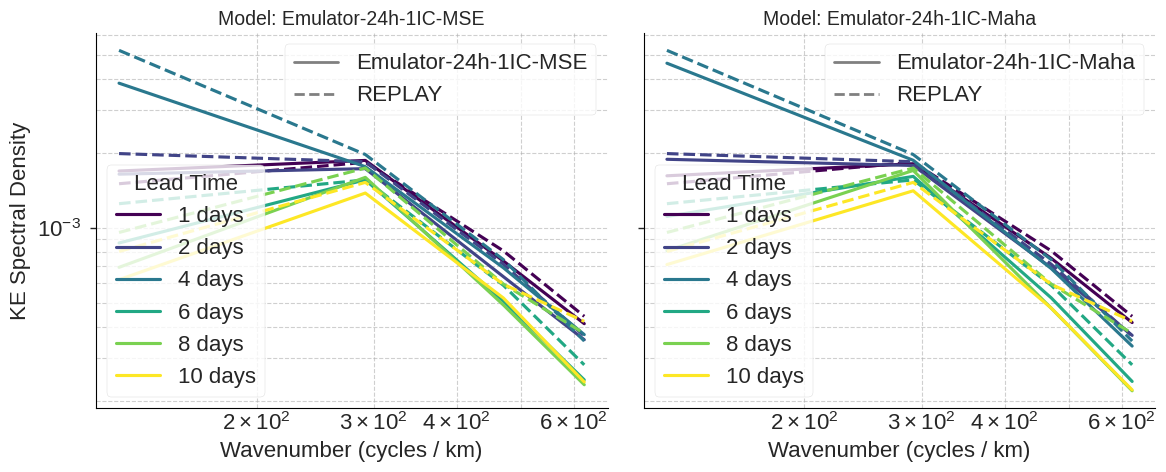

In [13]:
print("Plotting 1D spectra using xrft...")
# Setup the multi-panel plot
num_models = len(model_inferences)
fig, axes = plt.subplots(1, num_models, figsize=(num_models * 6, 5), 
                         sharey=True, squeeze=False)
axes = axes.flatten()

# Get the single reference truth dataset and its name
truth_ds = list(reference_truths.values())[0]
truth_name = list(reference_truths.keys())[0]

# Get the colormap for lead times
num_leads = len(leads_to_plot_td)
colors = mcm.viridis(np.linspace(0, 1, num_leads))

# Iterate over each model to create a panel
for i, (model_name, model_ds) in enumerate(model_inferences.items()):
    print("model_name:", model_name)
    ax = axes[i]
    
    # Iterate through our hand-picked list of lead times
    for j, lead_td in enumerate(leads_to_plot_td):
        print("lead_time:", lead_td)
        color = colors[j]
        label = f"{leads_to_plot_days[j]} days"
        
        # Check if this lead time exists in both model and truth
        if (lead_td not in model_ds['lead_time'].values) or \
           (lead_td not in truth_ds['lead_time'].values):
            print(f"Skipping lead time {label}: not found in all datasets.")
            continue
            
        # Select data for this specific lead time
        model_data_lead = model_ds.sel(lead_time=lead_td).isel(time=0)
        truth_data_lead = truth_ds.sel(lead_time=lead_td).isel(time=0)

        #model_data_lead['uo'].isel(z_l=0).sel({"lat": slice(lat_bounds[0], lat_bounds[1]), 
        # "lon": slice(lon_bounds[0], lon_bounds[1])}).plot()
        #plt.show()

        #truth_data_lead['uo'].isel(z_l=0).sel({"lat": slice(lat_bounds[0], lat_bounds[1]), 
        # "lon": slice(lon_bounds[0], lon_bounds[1])}).plot()
        #plt.show()
        
        try:
            ke_spec_1d_model = compute_ke_iso_spectrum(
                model_data_lead['uo'], model_data_lead['vo'],
                is_global=False, lat_bounds=lat_bounds, 
                lon_bounds=lon_bounds, lat_dim="lat", lon_dim="lon"
            )
            
            ke_spec_1d_truth = compute_ke_iso_spectrum(
                truth_data_lead['uo'], truth_data_lead['vo'],
                is_global=False, lat_bounds=lat_bounds,
                lon_bounds=lon_bounds, lat_dim="lat", lon_dim="lon"
            )

            # The wavenumber coordinate is 'freq_r'
            k_model = ke_spec_1d_model['freq_r'].values
            k_truth = ke_spec_1d_truth['freq_r'].values

            # Plot model (solid) and truth (dashed)
            ax.plot(k_model * 1000, ke_spec_1d_model.sel(z_l=z_l, method="nearest").values, color=color, label=label)
            ax.plot(k_truth * 1000, ke_spec_1d_truth.sel(z_l=z_l, method="nearest").values, color=color, linestyle='--')
            
        except Exception as e:
            print(f"Could not compute spectrum for {model_name} at lead {label}: {e}")

    # --- Format the panel ---
    ax.set_title(f"Model: {model_name}", fontsize=14)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.6)
    ax.set_xlabel('Wavenumber (cycles / km)')
    
    # Create two separate legends
    leg1 = ax.legend(title="Lead Time", loc='lower left')
    legend_elements = [
        Line2D([0], [0], color='gray', lw=2, label=model_name),
        Line2D([0], [0], color='gray', lw=2, linestyle='--', label=truth_name)
    ]
    leg2 = ax.legend(handles=legend_elements, loc='upper right')
    ax.add_artist(leg1)

# Set the y-label only for the first panel
axes[0].set_ylabel('KE Spectral Density')
plt.tight_layout()
plt.show()

## 2D Power Spectrum

In [20]:
# Define the lat/lon box
# Gulf Stream
lat_bounds = (45, 30)
lon_bounds = (150, 180)
z_l = 0 # level (in m)
itime = 0

# Define the lead times (in days) to analyze
leadtime_to_plot = 10  # in days
leadtime_to_plot_td = pd.to_timedelta(leadtime_to_plot, unit="D")

Plotting 2D spectra using xrft...


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


model_name: Emulator-24h-1IC-MSE
model_name: Emulator-24h-1IC-Maha


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
 

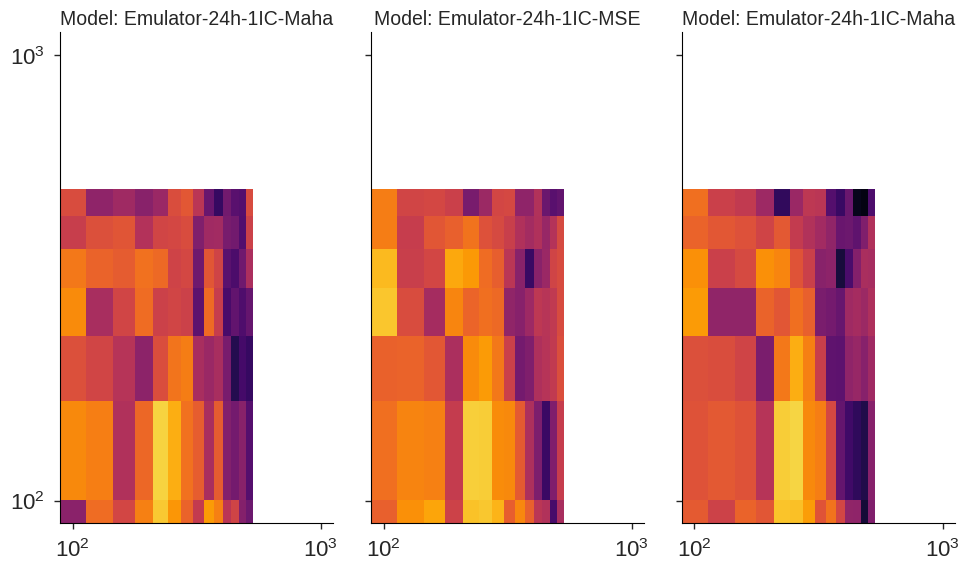

In [26]:
print("Plotting 2D spectra using xrft...")
# Setup the multi-panel plot
num_models = len(model_inferences)
fig, axes = plt.subplots(1, num_models+1, figsize=(num_models * 5, 6), 
                         sharey=True, squeeze=False)
axes = axes.flatten()

# Get the single reference truth dataset and its name
truth_ds = list(reference_truths.values())[0]
truth_name = list(reference_truths.keys())[0]

##### First: Reference truth #####
if leadtime_to_plot_td not in truth_ds['lead_time'].values:
    raise ValueError(f"leadtime={leadtime_to_plot} days not found in the reference truth inferences")
    
# get the reference truth inference for this lead time, this level and the first IC 
truth_data_lead = truth_ds.sel(lead_time=lead_td).sel(z_l=z_l, method="nearest").isel(time=itime)

# compute spectra
ke_spec_2d_truth = compute_ke_2d_spectrum(
    truth_data_lead['uo'], truth_data_lead['vo'],
    is_global=False, lat_bounds=lat_bounds,
    lon_bounds=lon_bounds, lat_dim="lat", lon_dim="lon",
)

# get the wavenumber/frequency
kx_truth = ke_spec_2d_truth['freq_lat'].values
ky_truth = ke_spec_2d_truth['freq_lat'].values

# Plot
im = axes[0].pcolormesh(ke_spec_2d_truth.freq_lon*1e3, ke_spec_2d_truth.freq_lat*1e3, 
                        ke_spec_2d_truth, norm=mcolors.LogNorm())
# --- Format the panel ---
axes[0].set_title(f"Model: {model_name}", fontsize=14)
axes[0].set_yscale('log')
axes[0].set_xscale('log')

##### Now iterate over all models #####
for i, (model_name, model_ds) in enumerate(model_inferences.items(), start=1):
    print("model_name:", model_name)
    ax = axes[i]
        
    # Check if this lead time exists in model inferences 
    if leadtime_to_plot_td not in model_ds['lead_time'].values: 
        raise ValueError(f"leadtime={leadtime_to_plot} days not found in {model_name} inferences")
            
    # Select data for this specific lead time
    model_data_lead = model_ds.sel(lead_time=lead_td).sel(z_l=z_l, method="nearest").isel(time=itime)
    
    #model_data_lead['uo'].isel(z_l=0).sel({"lat": slice(lat_bounds[0], lat_bounds[1]), 
    # "lon": slice(lon_bounds[0], lon_bounds[1])}).plot()
    #plt.show()

    #truth_data_lead['uo'].isel(z_l=0).sel({"lat": slice(lat_bounds[0], lat_bounds[1]), 
    # "lon": slice(lon_bounds[0], lon_bounds[1])}).plot()
    #plt.show()
        
    try:
        ke_spec_2d_model = compute_ke_2d_spectrum(
            model_data_lead['uo'], model_data_lead['vo'],
            is_global=False, lat_bounds=lat_bounds, 
            lon_bounds=lon_bounds, lat_dim="lat", lon_dim="lon",
        )

        # get the wavenumber/frequency
        kx_model = ke_spec_2d_model['freq_lat'].values
        ky_model = ke_spec_2d_model['freq_lat'].values
        

        # Plot
        im = ax.pcolormesh(ke_spec_2d_model.freq_lon*1e3, ke_spec_2d_model.freq_lat*1e3, 
                           ke_spec_2d_model, norm=mcolors.LogNorm())
        

    except Exception as e:
        print(f"Could not compute spectrum for {model_name} at lead {label}: {e}")

    # --- Format the panel ---
    ax.set_title(f"Model: {model_name}", fontsize=14)
    ax.set_yscale('log')
    ax.set_xscale('log')

#plt.colorbar()
plt.tight_layout()
plt.show()